[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]
(https://github.com/Dragomier/Machine_Learning_2026/edit/main/Homework1.ipynb)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits import mplot3d

In [6]:
source = "https://raw.githubusercontent.com/SzymonNowakowski/Machine-Learning-2025L/refs/heads/master/PCA_three_clusters_data.csv"
clusters = pd.read_csv(source)
clusters.head(10)

,x,y,z,class
0,0.647689,-0.138264,3.512299,0
1,-0.234137,-0.234153,10.769447,0
2,-0.469474,0.767435,11.166721,0
3,-0.465730,-0.463418,3.836479,0
4,-1.724918,-1.913280,1.710932,0
5,0.314247,-1.012831,-3.975973,0
6,1.465649,-1.412304,-6.420700,0
7,-1.424748,0.067528,-1.596480,0
8,-1.150994,0.110923,-3.849367,0
9,-0.291694,-0.600639,2.656586,0


# Firstly, we perform PCA on the 'clusters' data and plot it to check if it successfully clusters our data.

In [15]:
# Skalujemy dane i przeprowadzamy PCA
scaler = StandardScaler()

data = clusters[['x', 'y', 'z']]
data = scaler.fit_transform(data)

n_components = 2
pca = PCA(n_components = n_components)
pca_data = pca.fit_transform(data)

<Axes: >

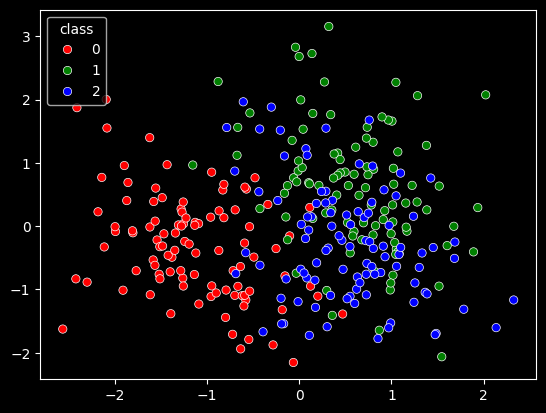

In [22]:
# Szkicujemy wykres
palette = {
    0: "red",
    1: "green",
    2: "blue"
}

sns.scatterplot(
    x=pca_data[:, 0],
    y=pca_data[:, 1],
    hue=clusters["class"],
    palette = palette
)

# The effects did not satisfy us enough, so we are projecting our data to "XY", "XZ" and "YZ" axes to check if this does a better job.

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette = {
    0: "red",
    1: "green",
    2: "blue"
}

sns.scatterplot(
    data = clusters,
    x = "x",
    y = "y",
    hue = "class",
    ax = axes[0],
    palette = palette
)
axes[0].set_title("Comparison of 'x' and 'y' features")

sns.scatterplot(
    data = clusters,
    x = "x",
    y = "z",
    hue = "class",
    palette = palette,
    ax = axes[1]
)
axes[1].set_title("Comparison of 'x' and 'z' features")

sns.scatterplot(
    data = clusters,
    x = "y",
    y = "z",
    hue = "class",
    palette = palette,
    ax = axes[2]
)
axes[2].set_title("Comparison of 'y' and 'z' features")

<IPython.core.display.Javascript object>

Text(0.5, 1.0, "Comparison of 'y' and 'z' features")

In [39]:
%matplotlib notebook
fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")
palette = {
    0: "red",
    1: "green",
    2: "blue"
}
point_colors = clusters["class"].map(palette)
ax.scatter3D(clusters.x, clusters.y, clusters.z, c = point_colors)
plt.title("Class of an object depending on 'x', 'y' and 'z' features")
plt.show()

<IPython.core.display.Javascript object>

# Results
__-- Projection on the 'XY' plane does better job than PCA__